In [5]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# modules
from src.circuit_generator import generate_random_circuit
from src.transformations import (
    identity_transformation, barrier_only, commute_independent,
    fault_add_x, fault_remove_random_gate, fault_change_target_qubit
)
from src.runners import run_circuit
from src.checker import check_violation

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

In [11]:
# CONFIG
NUM_TESTS = 300
SHOTS = 20000
BASE_SEED = 1000
TVD_THRESHOLD = 0.05
CHI_ALPHA = 0.05

# Batch experiments

In [12]:
project_root = Path.cwd().parent
results_dir = project_root / "results"
figures_dir =  results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# RELATIONS

VALID_RELATIONS = {
    "identity": identity_transformation,
    "barrier": barrier_only,
    "commute": commute_independent,
}

FAULT_RELATIONS = {
    "fault_add_x": fault_add_x,
    "fault_remove_random": fault_remove_random_gate,
    "fault_change_target_qubit":fault_change_target_qubit,
}

# RUN EXPERIMENT 
results = []

print(f"Running {NUM_TESTS} tests per relation...\n")

for i in range(NUM_TESTS):
    seed = BASE_SEED + i
    qc = generate_random_circuit(4, 10, add_measurements=True, seed=seed)
    counts_src = run_circuit(qc, shots=SHOTS)

    # Valid Relations
    for name, transform in VALID_RELATIONS.items():
        qc_f = transform(qc, seed=seed) if name == "commute" else transform(qc)
        counts_f = run_circuit(qc_f, shots=SHOTS)

        tvd_viol, tvd_dist, chi_viol, p_val, _ = check_violation(
            counts_src, counts_f, 
            tvd_threshold=TVD_THRESHOLD, 
            chi_alpha=CHI_ALPHA
        )

        results.append({
            "test_id": i + 1,
            "relation": name,
            "type": "valid",
            "tvd": round(tvd_dist, 4),
            "p_value": round(p_val, 4),
            "violation": tvd_viol or chi_viol
        })

    # Fault Relations
    for name, transform in FAULT_RELATIONS.items():
        qc_f = transform(qc)
        if not any(instr.operation.name == 'measure' for instr in qc_f.data):
            qc_f = qc_f.copy()
            qc_f.measure_all()

        counts_f = run_circuit(qc_f, shots=SHOTS)

        tvd_viol, tvd_dist, chi_viol, p_val, _ = check_violation(
            counts_src, counts_f,
            tvd_threshold=TVD_THRESHOLD, 
            chi_alpha=CHI_ALPHA
        )

        results.append({
            "test_id": i + 1,
            "relation": name,
            "type": "fault",
            "tvd": round(tvd_dist, 4),
            "p_value": round(p_val, 4),
            "violation": tvd_viol or chi_viol,
            "expected_violation": True
        })

# SAVE 
df = pd.DataFrame(results)

# Save raw data
df.to_csv(results_dir/"metamorphic_random_circuit_results.csv", index=False)

# Summary Table
summary = df.groupby(["relation", "type"]).agg(
    tests=("violation", "count"),
    violations=("violation", "sum"),
    violation_rate=("violation", "mean"),
    avg_tvd=("tvd", "mean"),
    avg_p=("p_value", "mean"),
    max_tvd=("tvd", "max")
).round(4)

summary["violation_rate"] = (summary["violation_rate"] * 100).round(2)
summary.to_csv(results_dir/"random_circuit_summary_table.csv")

print("\n=== SUMMARY ===")
display(summary)

Running 300 tests per relation...


=== SUMMARY ===


,,tests,violations,violation_rate,avg_tvd,avg_p,max_tvd
relation,type,,,,,,
barrier,valid,300,9,3.00,0.0059,0.5507,0.0195
commute,valid,300,13,4.33,0.0058,0.5690,0.0182
fault_add_x,fault,300,189,63.00,0.6096,0.2047,1.0000
fault_change_target_qubit,fault,300,186,62.00,0.4719,0.2388,1.0000
fault_remove_random,fault,300,214,71.33,0.5095,0.1629,1.0000
identity,valid,300,9,3.00,0.0055,0.6018,0.0179


# Quick statistics & plots

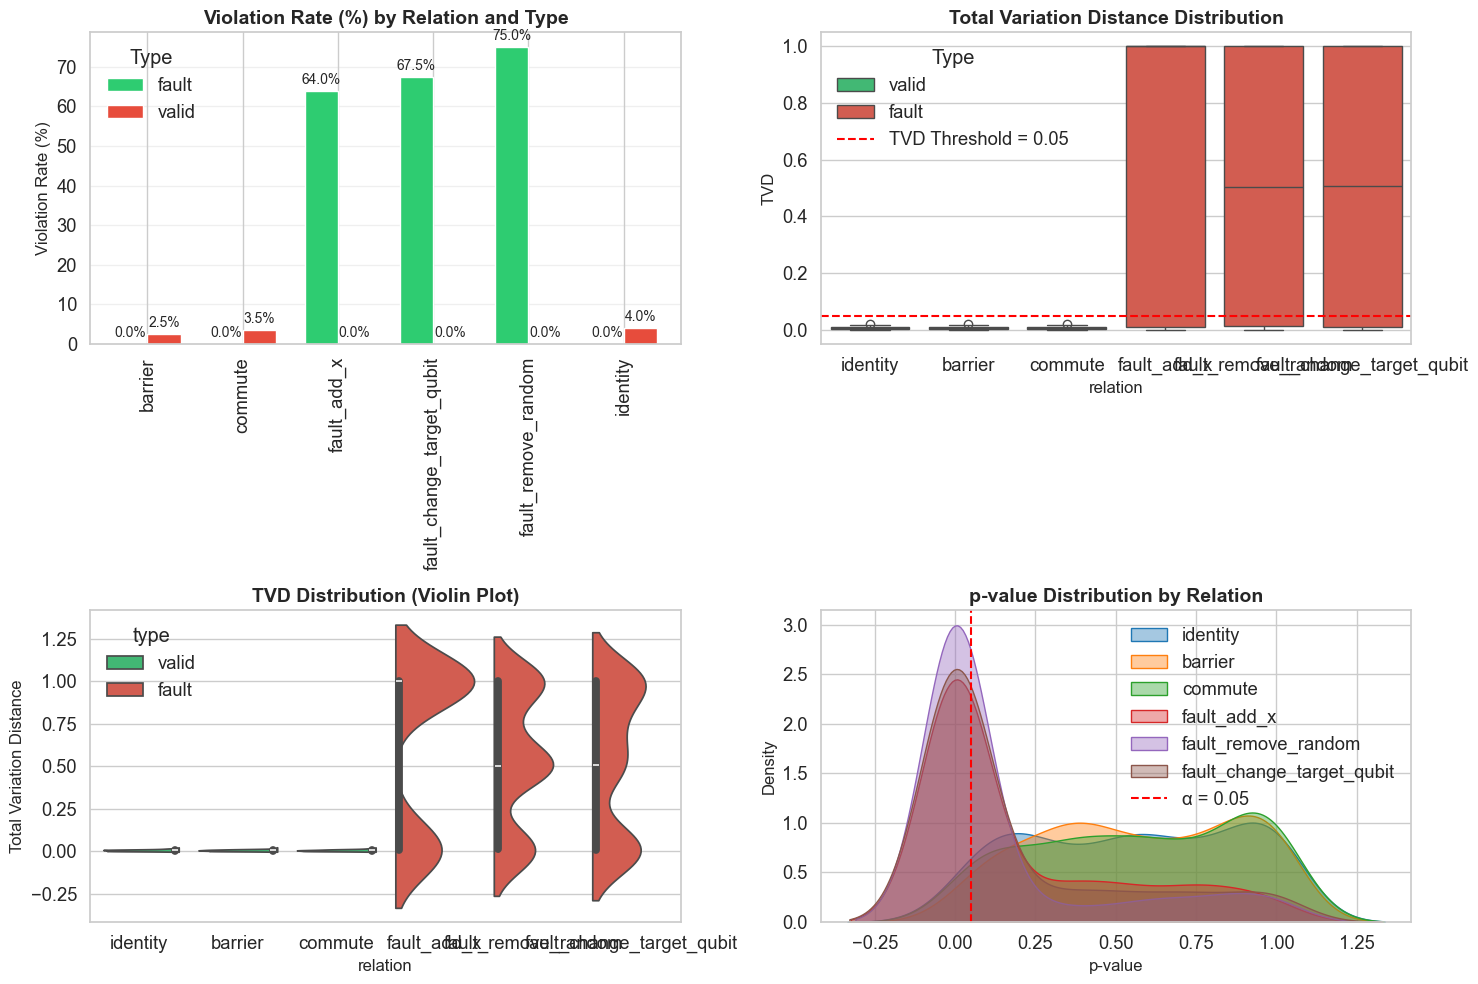

In [7]:
# Set style
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# VISUALIZATIONS 

fig = plt.figure(figsize=(15, 10))

# 1. Violation Rate Comparison

ax1 = plt.subplot(2, 2, 1)
violation_rates = df.groupby(["relation", "type"])["violation"].mean().unstack() * 100
violation_rates.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], width=0.7)
ax1.set_title("Violation Rate (%) by Relation and Type", fontweight='bold')
ax1.set_ylabel("Violation Rate (%)")
ax1.set_xlabel("")
ax1.legend(title="Type", loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=10)

# 2. TVD Boxplot 

ax2 = plt.subplot(2, 2, 2)
sns.boxplot(data=df, x="relation", y="tvd", hue="type", ax=ax2, palette=['#2ecc71', '#e74c3c'])
ax2.axhline(TVD_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'TVD Threshold = {TVD_THRESHOLD}')
ax2.set_title("Total Variation Distance Distribution", fontweight='bold')
ax2.set_ylabel("TVD")
ax2.legend(title="Type")

# 3. TVD Violin Plot

ax3 = plt.subplot(2, 2, 3)
sns.violinplot(data=df, x="relation", y="tvd", hue="type", ax=ax3, 
               palette=['#2ecc71', '#e74c3c'], split=True)
ax3.set_title("TVD Distribution (Violin Plot)", fontweight='bold')
ax3.set_ylabel("Total Variation Distance")

# 4. p-value Distribution

ax4 = plt.subplot(2, 2, 4)
for rel in df["relation"].unique():
    subset = df[df["relation"] == rel]
    sns.kdeplot(data=subset, x="p_value", label=rel, fill=True, alpha=0.4, ax=ax4)
ax4.axvline(CHI_ALPHA, color='red', linestyle='--', label=f'α = {CHI_ALPHA}')
ax4.set_title("p-value Distribution by Relation", fontweight='bold')
ax4.set_xlabel("p-value")
ax4.legend()

plt.tight_layout()
plt.savefig(figures_dir / "metamorphic_results_random_circuit.pdf", dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / "metamorphic_results_random_circuit.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# THRESHOLD TUNING 

TVD_VALUES = [0.01, 0.02, 0.03, 0.04, 0.05, 0.055, 0.06, 0.07]
CHI_VALUES = [0.01, 0.05, 0.10]

tuning_results = []

for tvd_th in TVD_VALUES:
    for chi_a in CHI_VALUES:
        violation_tuned = (df["tvd"] > tvd_th) | (df["p_value"] < chi_a)
        
        valid = df["type"] == "valid"
        fault = df["type"] == "fault"
        
        fp = violation_tuned[valid].mean()      
        tp = violation_tuned[fault].mean()     
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        tuning_results.append({
            "tvd_threshold": tvd_th,
            "chi_alpha": chi_a,
            "fp_rate (%)": round(fp * 100, 2),
            "tp_rate (%)": round(tp * 100, 2),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4)
        })

df_tuning = pd.DataFrame(tuning_results)

# Show best configurations with reasonable false positives
df_best = df_tuning[df_tuning["fp_rate (%)"] <= 10].sort_values(
    by="f1_score", ascending=False
).head(12)

display(df_best)
df_best.to_csv(results_dir/"threshold_tuning_1.csv", index=False)

,tvd_threshold,chi_alpha,fp_rate (%),tp_rate (%),precision,recall,f1_score
6,0.030,0.01,1.17,68.17,0.9832,0.6817,0.8051
18,0.060,0.01,1.17,68.17,0.9832,0.6817,0.8051
15,0.055,0.01,1.17,68.17,0.9832,0.6817,0.8051
12,0.050,0.01,1.17,68.17,0.9832,0.6817,0.8051
9,0.040,0.01,1.17,68.17,0.9832,0.6817,0.8051
21,0.070,0.01,1.17,68.17,0.9832,0.6817,0.8051
3,0.020,0.01,1.33,68.17,0.9808,0.6817,0.8043
4,0.020,0.05,3.33,68.83,0.9538,0.6883,0.7996
7,0.030,0.05,3.33,68.83,0.9538,0.6883,0.7996
22,0.070,0.05,3.33,68.83,0.9538,0.6883,0.7996


<Figure size 1000x600 with 0 Axes>

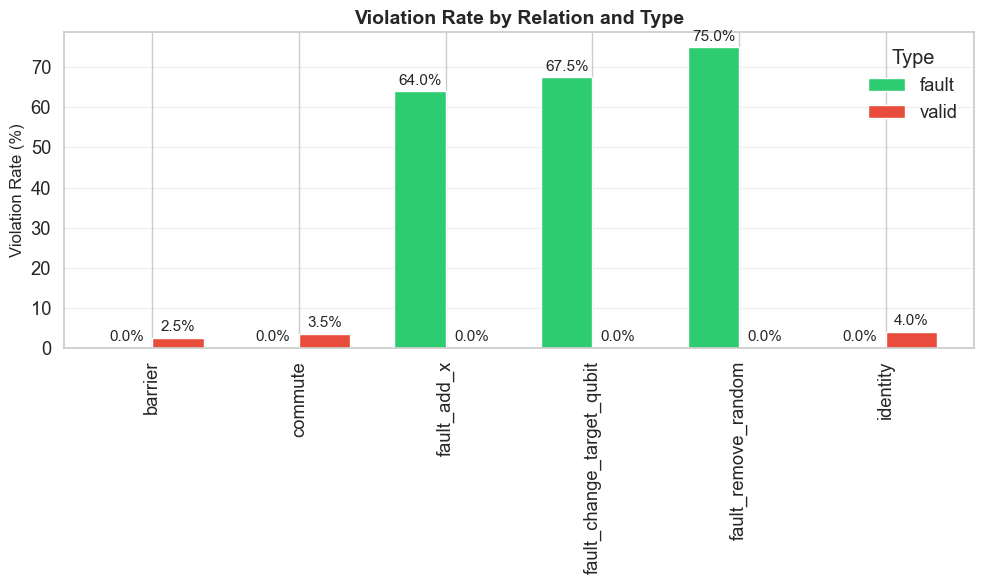

In [10]:
# 1. Violation Rate Comparison

plt.figure(figsize=(10, 6))
violation_rates = df.groupby(["relation", "type"])["violation"].mean().unstack() * 100

ax = violation_rates.plot(kind='bar', color=['#2ecc71', '#e74c3c'], width=0.7)
plt.title("Violation Rate by Relation and Type", fontweight='bold')
plt.ylabel("Violation Rate (%)")
plt.xlabel("")
plt.legend(title="Type")
plt.grid(axis='y', alpha=0.3)

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.8, 
            f'{height:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(figures_dir / "violation_rate_bar_RC.pdf", dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / "violation_rate_bar_RC.png", dpi=300, bbox_inches='tight')
plt.show()

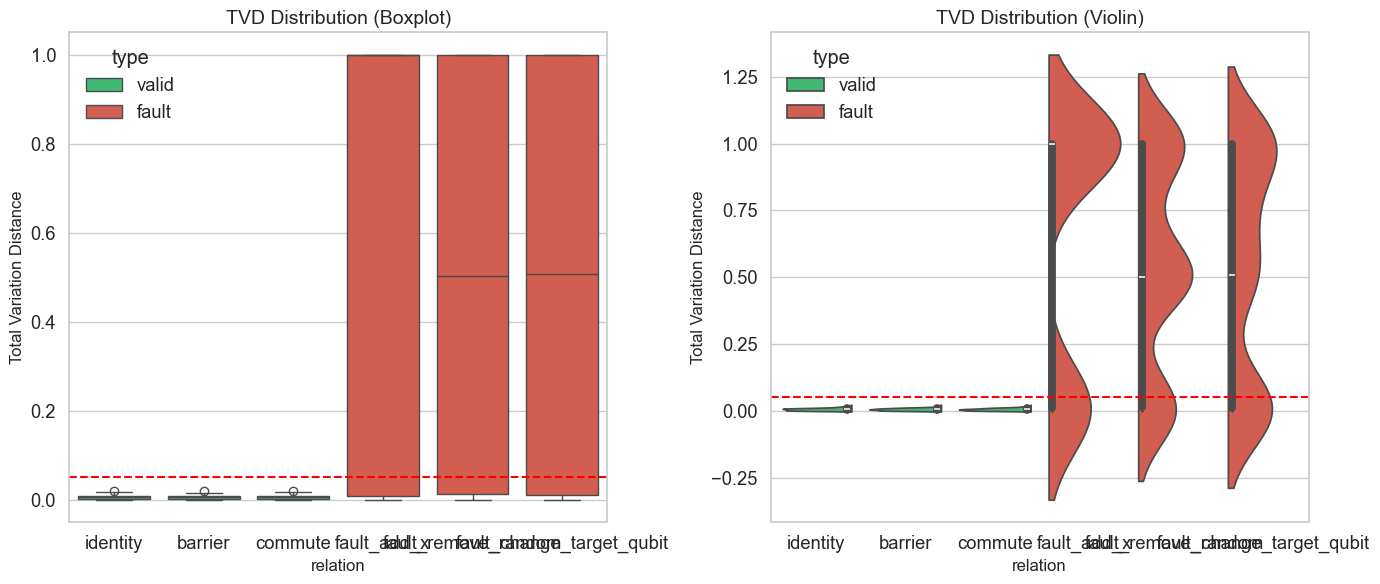

In [11]:

# 2. TVD Distribution Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(data=df, x="relation", y="tvd", hue="type", ax=axes[0], 
            palette=['#2ecc71', '#e74c3c'])
axes[0].axhline(TVD_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title("TVD Distribution (Boxplot)")
axes[0].set_ylabel("Total Variation Distance")

# Violin Plot
sns.violinplot(data=df, x="relation", y="tvd", hue="type", ax=axes[1], 
               palette=['#2ecc71', '#e74c3c'], split=True)
axes[1].axhline(TVD_THRESHOLD, color='red', linestyle='--')
axes[1].set_title("TVD Distribution (Violin)")
axes[1].set_ylabel("Total Variation Distance")

plt.tight_layout()
plt.savefig(figures_dir / "tvd_distribution_RC.pdf", dpi=300, bbox_inches='tight')
plt.show()

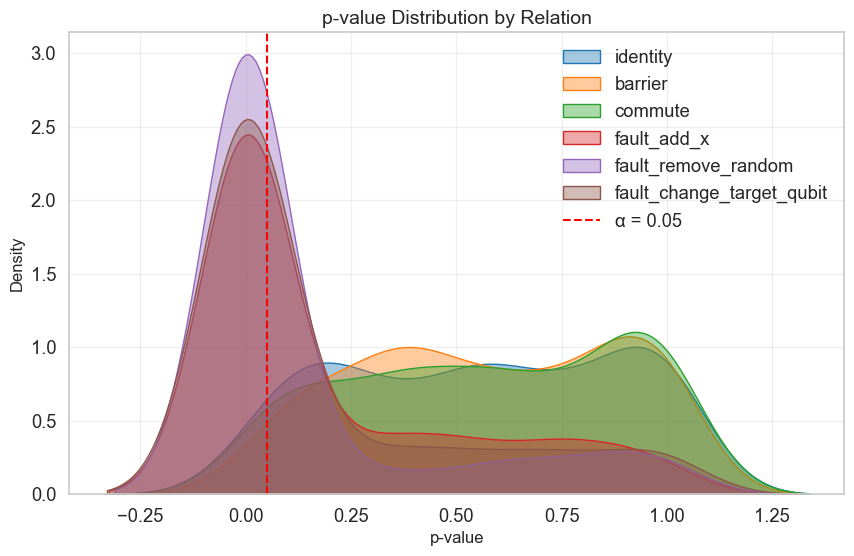

In [12]:
# 3. p-value Distribution

plt.figure(figsize=(10, 6))

for rel in df["relation"].unique():
    subset = df[df["relation"] == rel]
    sns.kdeplot(data=subset, x="p_value", label=rel, fill=True, alpha=0.4)

plt.axvline(CHI_ALPHA, color='red', linestyle='--', label=f'α = {CHI_ALPHA}')
plt.title("p-value Distribution by Relation")
plt.xlabel("p-value")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(figures_dir / "pvalue_distribution_RC.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [13]:

# Final Summary

print("===================== FINAL SUMMARY TABLE ======================")
display(summary)

summary.to_csv(results_dir/"RC_summary_table.csv")
df.to_csv(results_dir/"RC_full_results.csv", index=False)

=== FINAL SUMMARY TABLE ===


,,tests,violations,violation_rate,avg_tvd,avg_p,max_tvd
relation,type,,,,,,
barrier,valid,200,5,2.5,0.0057,0.5742,0.0203
commute,valid,200,7,3.5,0.0057,0.5763,0.0193
fault_add_x,fault,200,128,64.0,0.6327,0.1998,1.0000
fault_change_target_qubit,fault,200,135,67.5,0.5351,0.1855,1.0000
fault_remove_random,fault,200,150,75.0,0.5429,0.1465,1.0000
identity,valid,200,8,4.0,0.0058,0.5575,0.0197



✅ All results and figures saved in 'results/' folder
   • Tables: results/summary_table_RC.csv
   • Raw data: results/full_results_RC.csv
   • Figures: results/figures/
